This notebook analyses where the bottlenecks in the process are in order to improve speed

In [1]:
import pytest
import geopandas as gpd
import json
from pathlib import Path
import sys

sys.path.insert(0, '../../src')

import park_vga

import cProfile
import pstats


In [2]:
TEST_PARK_NAME = "Chapel Allerton Park"

output_folder = "optimisation_test_output"

DATA_DIR = "../../example_datasets/"

dsm_path = "../../tests/test_data_england/DSM"
dtm_path = "../../tests/test_data_england/DTM"

boundaries_file = str(DATA_DIR + 'Leeds_pp_or_g_cmb.geojson')

In [3]:
boundaries_file

'../../example_datasets/Leeds_pp_or_g_cmb.geojson'

In [4]:
profiler = cProfile.Profile()
profiler.enable()

In [5]:
park_n = park_vga.workflow.find_park_n(TEST_PARK_NAME, boundaries_file)

In [6]:
results = park_vga.workflow.workflow_eng(boundaries_file, park_n,
                                         dtm_path, dsm_path,
                                         output_folder,
                                         return_results=True, save_results=True)

Output directory already exists at optimisation_test_output
Park ID: LEEDS_945491c73c1c
Park ID for file name: leeds_945491c73c1c
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(430885.41992692224, 437280.3589293043), (430885.41992692224, 437631.61221827124), (430544.1449808032, 437631.61221827124), (430544.1449808032, 437280.3589293043)]
Grid refs for corners: ['SE33nw', 'SE33nw', 'SE33nw', 'SE33nw']
Tile name(s): {'SE33nw'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['../../tests/test_data_england/DTM/SE33nw_DTM_2m.tif'] 
DSM paths: ['../../tests/test_data_england/DSM/SE33nw_FZ_DSM_2m.tif']
Files found for park 1
Created 517 pointy-top hexagons (10m vertical spacing)
Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (176, 171), Height range: -0.0m to 25.1m
Start calculating visibility. This will take a few mins
Calculating visibility 

In [7]:
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

         50879184 function calls (50858092 primitive calls) in 26.104 seconds

   Ordered by: cumulative time
   List reduced from 2942 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   115/84    0.022    0.000   51.332    0.611 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
   116/36    0.030    0.000   26.090    0.725 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
   116/36    0.013    0.000   26.089    0.725 {method 'run' of '_contextvars.Context' objects}
        3    0.000    0.000   26.079    8.693 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:597(shell_main)
        3    0.000    0.000   26.078    8.693 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:398(dispatch_shell)
        3    0.000    0.000   26.068    8.689 /Users/m

Results pre-refactoring:

```
126752654 function calls (125409738 primitive calls) in 58.207 seconds

   Ordered by: cumulative time
   List reduced from 1559 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   116/83    0.002    0.000  115.906    1.396 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
   117/38    0.000    0.000   58.196    1.531 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
   117/38    0.029    0.000   58.196    1.531 {method 'run' of '_contextvars.Context' objects}
    74/70    0.000    0.000   58.195    0.831 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:573(_handle_events)
    49/46    0.000    0.000   58.192    1.265 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/tornado/platform/asyncio.py:206(_handle_events)
        3    0.000    0.000   58.184   19.395 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/ipkernel.py:374(do_execute)
        3    0.000    0.000   58.180   19.393 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/zmqshell.py:660(run_cell)
        3    0.000    0.000   58.180   19.393 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3131(run_cell)
        3    0.000    0.000   58.180   19.393 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3179(_run_cell)
        3    0.000    0.000   58.179   19.393 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/async_helpers.py:119(_pseudo_sync_runner)
        3    0.000    0.000   58.179   19.393 {method 'send' of 'coroutine' objects}
        3    0.001    0.000   58.179   19.393 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3285(run_cell_async)
        3    0.000    0.000   58.177   19.392 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3589(run_ast_nodes)
        3    0.000    0.000   58.177   19.392 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3712(run_code)
     13/3    0.000    0.000   58.176   19.392 {built-in method builtins.exec}
        1    0.407    0.407   56.907   56.907 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:394(calculate_visibility_metrics)
    90060    1.899    0.000   39.930    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:335(check_line_of_sight)
  1098331    0.576    0.000   27.028    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:326(get_elevation_at_point)
  1098331    1.200    0.000   26.449    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:320(point_to_raster_index)
  1098331    1.548    0.000   19.213    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/rasterio/transform.py:255(rowcol)

```

with some initial modifications to vectorise:

```
         80261391 function calls (80240302 primitive calls) in 41.829 seconds

   Ordered by: cumulative time
   List reduced from 2941 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   114/83    0.002    0.000   63.615    0.766 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
   115/34    0.001    0.000   40.890    1.203 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
        3    0.000    0.000   40.873   13.624 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/ipkernel.py:374(do_execute)
        3    0.000    0.000   40.870   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/zmqshell.py:660(run_cell)
        3    0.000    0.000   40.870   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3131(run_cell)
        3    0.000    0.000   40.870   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3179(_run_cell)
        3    0.000    0.000   40.869   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/async_helpers.py:119(_pseudo_sync_runner)
        3    0.000    0.000   40.869   13.623 {method 'send' of 'coroutine' objects}
        3    0.000    0.000   40.869   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3285(run_cell_async)
        3    0.000    0.000   40.868   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3589(run_ast_nodes)
        3    0.000    0.000   40.868   13.623 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3712(run_code)
    304/3    0.003    0.000   40.867   13.622 {built-in method builtins.exec}
    90060    1.833    0.000   38.876    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:344(check_line_of_sight)
  1098331    0.563    0.000   26.309    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:334(get_elevation_at_point)
  1098331    1.198    0.000   25.739    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:320(point_to_raster_index)
  1098332    1.527    0.000   18.719    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/rasterio/transform.py:255(rowcol)
        1    0.044    0.044   17.233   17.233 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:466(calculate_visibility_metrics)
  1098332    2.491    0.000   15.310    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/rasterio/transform.py:363(rowcol)
  3515319    3.683    0.000    9.881    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/shapely/decorators.py:73(wrapped)
   919291    1.381    0.000    7.936    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/shapely/geometry/point.py:54(__new__)

```

Removing point creation:

```
         50879184 function calls (50858092 primitive calls) in 26.104 seconds

   Ordered by: cumulative time
   List reduced from 2942 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   115/84    0.022    0.000   51.332    0.611 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
   116/36    0.030    0.000   26.090    0.725 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
   116/36    0.013    0.000   26.089    0.725 {method 'run' of '_contextvars.Context' objects}
        3    0.000    0.000   26.079    8.693 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:597(shell_main)
        3    0.000    0.000   26.078    8.693 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:398(dispatch_shell)
        3    0.000    0.000   26.068    8.689 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/ipkernel.py:374(do_execute)
        3    0.000    0.000   26.065    8.688 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/zmqshell.py:660(run_cell)
        3    0.000    0.000   26.065    8.688 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3131(run_cell)
        3    0.000    0.000   26.065    8.688 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3179(_run_cell)
        3    0.000    0.000   26.064    8.688 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/async_helpers.py:119(_pseudo_sync_runner)
        3    0.000    0.000   26.064    8.688 {method 'send' of 'coroutine' objects}
        3    0.000    0.000   26.064    8.688 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3285(run_cell_async)
        3    0.000    0.000   26.063    8.688 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3589(run_ast_nodes)
        3    0.000    0.000   26.062    8.687 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3712(run_code)
    304/3    0.003    0.000   26.062    8.687 {built-in method builtins.exec}
    90060    1.514    0.000   23.945    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:350(check_line_of_sight)
  1098332    1.432    0.000   17.741    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/rasterio/transform.py:255(rowcol)
   918211    0.648    0.000   15.381    0.000 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:344(point_to_raster_index_from_coords)
  1098332    2.402    0.000   14.541    0.000 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/rasterio/transform.py:363(rowcol)
        1    0.040    0.040   10.923   10.923 /Users/maeve/Documents/park-vga/notebooks/optimisation_and_speedup/../../src/park_vga/lidar.py:492(calculate_visibility_metrics)
```

<Axes: >

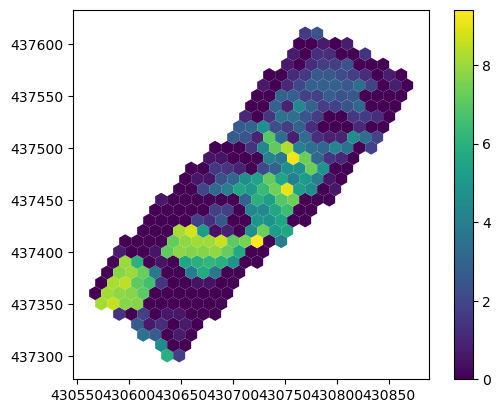

In [8]:
results[0].plot(column="visibility_pct", cmap="viridis", legend=True)

Plot to compare:

![alt text](image.png)